# MINOS 2D Event Display (Matplotlib)

This notebook loads the local ROOT SNTP file and renders the 2D MINOS perspectives for a given event index using Matplotlib.

- **2D Panel Display**:
  - Top Panel: Perspective 1 (U View: `planeview 2`)
  - Bottom Panel: Perspective 2 (V View: `planeview 3`)
- The two panels share the plane axis on x, while the strip axis is shown on y with the second perspective mirrored to reflect detector strip orientation.
- Pulse height from `ph0.pe` and `ph1.pe` is used as pixel intensity channel (`turbo` colormap).


In [1]:
%pip install -q uproot awkward numpy pandas matplotlib

from pathlib import Path
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot

root_file = Path('f21048000_0000_L010185N_D07_r3.sntp.dogwood5.0.root')
if not root_file.exists():
    root_file = Path('minos_sparse/f21048000_0000_L010185N_D07_r3.sntp.dogwood5.0.root')
assert root_file.exists(), f'Missing ROOT file: {root_file}'
print(f'Using ROOT file: {root_file}')


Note: you may need to restart the kernel to use updated packages.
Using ROOT file: f21048000_0000_L010185N_D07_r3.sntp.dogwood5.0.root


In [2]:
EVENT_INDEX = 6

root_handle = uproot.open(root_file)
tree = root_handle['NtpSt;1']
print(f'Loaded tree NtpSt;1 with {tree.num_entries} total events.')


Loaded tree NtpSt;1 with 119205 total events.


Event 6 MC Truth: nu_mu | Type: CC | Channel: DIS | True E_nu = 3.70 GeV


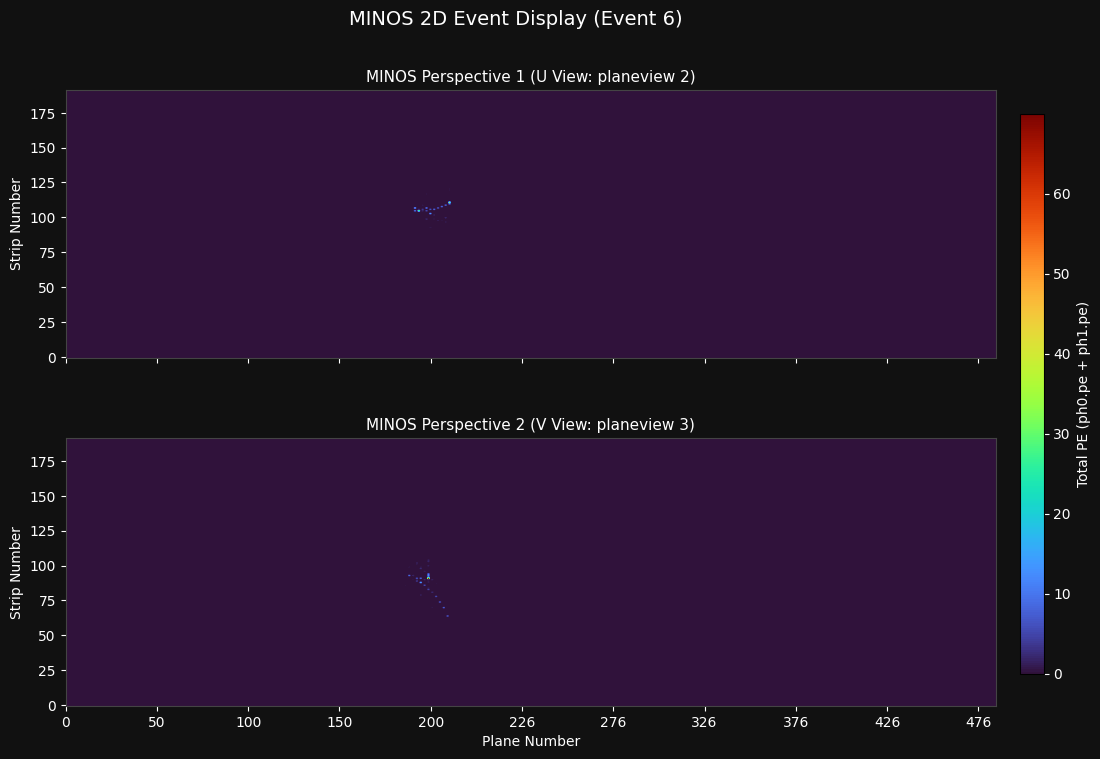

In [3]:
plane_min, plane_max = 1, 485
strip_min, strip_max = 0, 191
gap_columns = 24
gap_start = 244

# Global display planes (includes the gap offset for physical indexing)
all_disp_planes = [p if p < gap_start else p + gap_columns for p in range(plane_min, plane_max + 1)]
full_strips = list(range(strip_min, strip_max + 1))

tick_positions = list(range(0, 550, 50))
tick_text_list = [str(p) if p < gap_start else str(p - gap_columns) for p in tick_positions]

NEUTRINO_FLAVORS = {14: "nu_mu", -14: "nu_bar_mu", 12: "nu_e", -12: "nu_bar_e", 16: "nu_tau", -16: "nu_bar_tau"}
INTERACTION_CURRENTS = {1: "CC", 0: "NC"}
INTERACTION_CHANNELS = {1001: "QE", 1002: "RES", 1003: "DIS", 1004: "COH"}

req_branches = [
    "NtpStRecord/stp/stp.planeview",
    "NtpStRecord/stp/stp.strip",
    "NtpStRecord/stp/stp.plane",
    "NtpStRecord/stp/stp.ph0.pe",
    "NtpStRecord/stp/stp.ph1.pe",
    "NtpStRecord/mc/mc.inu",
    "NtpStRecord/mc/mc.iaction",
    "NtpStRecord/mc/mc.iresonance",
    "NtpStRecord/mc/mc.p4neu[4]",
]

event = tree.arrays(req_branches, entry_start=EVENT_INDEX, entry_stop=EVENT_INDEX+1, library="ak")[0]

planeview = ak.to_list(event["NtpStRecord/stp/stp.planeview"])
strip = ak.to_list(event["NtpStRecord/stp/stp.strip"])
plane = ak.to_list(event["NtpStRecord/stp/stp.plane"])
ph0_pe = ak.to_list(event["NtpStRecord/stp/stp.ph0.pe"])
ph1_pe = ak.to_list(event["NtpStRecord/stp/stp.ph1.pe"])
total_pe = [east + west for east, west in zip(ph0_pe, ph1_pe)]
vmax = max(total_pe) if total_pe else 1.0

# Print MC Truth
try:
    inu_val = ak.to_list(event["NtpStRecord/mc/mc.inu"])[0]
    iact_val = ak.to_list(event["NtpStRecord/mc/mc.iaction"])[0]
    ires_val = ak.to_list(event["NtpStRecord/mc/mc.iresonance"])[0]
    p4neu_val = ak.to_list(event["NtpStRecord/mc/mc.p4neu[4]"])[0]
    nu_str = NEUTRINO_FLAVORS.get(inu_val, f"PDG {inu_val}")
    curr_str = INTERACTION_CURRENTS.get(iact_val, f"Current {iact_val}")
    chan_str = INTERACTION_CHANNELS.get(ires_val, f"Code {ires_val}")
    e_nu_val = p4neu_val[3]
    print(f"Event {EVENT_INDEX} MC Truth: {nu_str} | Type: {curr_str} | Channel: {chan_str} | True E_nu = {e_nu_val:.2f} GeV")
except Exception:
    print(f"Event {EVENT_INDEX} MC Truth unavailable.")

# Build 2D Heatmap Arrays
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, facecolor="#111111")
fig.suptitle(f"MINOS 2D Event Display (Event {EVENT_INDEX})", color="white", fontsize=14)

images = []
# Fixed extent matching the physical bounds across all planes
global_extent = [all_disp_planes[0] - 0.5, all_disp_planes[-1] + 0.5, strip_min - 0.5, strip_max + 0.5]

for i, (view, ax, title) in enumerate([
    (2, ax1, "MINOS Perspective 1 (U View: planeview 2)"),
    (3, ax2, "MINOS Perspective 2 (V View: planeview 3)")
]):
    mask = [v == view for v in planeview]
    if not any(mask):
        img_vals = np.zeros((len(full_strips), len(all_disp_planes)))
    else:
        v_strip = [s for s, keep in zip(strip, mask) if keep]
        v_plane = [p for p, keep in zip(plane, mask) if keep]
        v_pe = [pe for pe, keep in zip(total_pe, mask) if keep]
        m_strip = [strip_max - s for s in v_strip] if i == 1 else v_strip
        disp_plane = [p if p < gap_start else p + gap_columns for p in v_plane]
        
        df = pd.DataFrame({"plane": disp_plane, "strip": m_strip, "pe": v_pe})
        pivot = df.pivot_table(index="strip", columns="plane", values="pe", aggfunc="sum", fill_value=0)
        
        # Reindex against all_disp_planes to introduce 0-value gaps for alternating planes
        pivot = pivot.reindex(index=full_strips, columns=all_disp_planes, fill_value=0)
        img_vals = pivot.values

    ax.set_facecolor("black")
    im = ax.imshow(
        img_vals, 
        aspect="auto", 
        origin="lower", 
        cmap="turbo", 
        vmin=0, 
        vmax=vmax,
        extent=global_extent
    )
    images.append(im)
    
    ax.set_title(title, color="white", fontsize=11)
    ax.set_ylabel("Strip Number", color="white")
    ax.tick_params(colors="white")
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_text_list)
    for spine in ax.spines.values():
        spine.set_color("#444444")

ax2.set_xlabel("Plane Number", color="white")

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(images[0], cax=cbar_ax)
cbar.set_label("Total PE (ph0.pe + ph1.pe)", color="white")
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.subplots_adjust(right=0.9, hspace=0.3)
plt.show()

In [4]:
from enum import Enum
from typing import Any
import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt

# ==============================================================================
# 1. CONSTANTS & DEFINITIONS
# ==============================================================================


# Enum corresponding to MINOS U/V plane views
class EPlaneView(Enum):
    UNKNOWN = 0
    U = 1
    V = 2


# MINOS Far Detector geometry numbers
MINOS_NUMBERS = {
    "FD": {
        "South": {"NPlanes": 249, "D": 14.78},
        "North": {"NPlanes": 237, "D": 14.10},
        "AirGap": {"D": 1.15},
        "NStripsPerPlane": 192,
    }
}


# ==============================================================================
# 2. LAYOUT & HELPER FUNCTIONS
# ==============================================================================


def fd_uv_views_layout(
    title: str = "Far Detector",
    use_real_distances: bool = False,
    **figure_kwargs,
) -> tuple[plt.Figure, tuple[plt.Axes, ...]]:
    """Creates a 2x3 grid layout for U-Z and V-Z plane views across South and North supermodules."""
    axs_edge_colour = plt.rcParams.get("axes.edgecolor", "#000000")

    fd_depths = np.asarray(
        [
            MINOS_NUMBERS["FD"]["South"]["D"],
            MINOS_NUMBERS["FD"]["AirGap"]["D"],
            MINOS_NUMBERS["FD"]["North"]["D"],
        ]
    )
    fd_depth_ratios = fd_depths / fd_depths.sum()

    fig, axs = plt.subplots(
        nrows=2,
        ncols=3,
        gridspec_kw={"width_ratios": fd_depth_ratios},
        constrained_layout=False,
        **figure_kwargs,
    )
    axs_flat = tuple(axs.flatten())

    fig.subplots_adjust(wspace=0)

    # Indicate air gap between supermodules
    for idx in (1, 4):
        axs_flat[idx].add_patch(
            patches.Rectangle(
                (0, 0),
                1,
                1,
                linewidth=0.5,
                edgecolor=axs_edge_colour,
                facecolor="none",
                hatch="//",
            )
        )

    # View labels
    axs_flat[0].text(
        0.07,
        0.87,
        "UZ Plane",
        fontdict=dict(fontsize=plt.rcParams.get("axes.titlesize", 12)),
        transform=axs_flat[0].transAxes,
    )
    axs_flat[3].text(
        0.07,
        0.87,
        "VZ Plane",
        fontdict=dict(fontsize=plt.rcParams.get("axes.titlesize", 12)),
        transform=axs_flat[3].transAxes,
    )

    y_label = "T (m)" if use_real_distances else "Strip Number"
    x_label = "Z (m)" if use_real_distances else "Plane Number"

    # Configure axes
    for ax in (axs_flat[0], axs_flat[3]):
        ax.tick_params(which="both", right=False)
        ax.set_ylabel(y_label)

    for ax in (axs_flat[1], axs_flat[4]):
        ax.set_yticks([])
        ax.set_xticks([])
        ax.set_yticklabels([])
        ax.set_xticklabels([])

    for ax in (axs_flat[2], axs_flat[5]):
        ax.tick_params(which="both", left=False, labelleft=False)

    axs_flat[2].set_title(title, loc="right", wrap=True)

    fig.supxlabel(
        x_label,
        fontsize=axs_flat[0].xaxis.label.get_fontsize(),
        transform=axs_flat[1].xaxis.label.get_transform(),
    )

    fig.subplots_adjust(bottom=0.08)

    return fig, axs_flat


def create_fd_split_image(
    plane: EPlaneView,
    stp_planeview: npt.NDArray,
    stp_strip: npt.NDArray,
    stp_plane: npt.NDArray,
    fill: list[npt.NDArray] | None = None,
) -> tuple[npt.NDArray, npt.NDArray]:
    """Generates 2D hit matrices for South and North supermodules for a specified plane view (U or V)."""
    s_n_planes: int = MINOS_NUMBERS["FD"]["South"]["NPlanes"]
    n_n_planes: int = MINOS_NUMBERS["FD"]["North"]["NPlanes"]
    n_strips: int = MINOS_NUMBERS["FD"]["NStripsPerPlane"]

    south_image = np.zeros((n_strips, s_n_planes), dtype=np.float64)
    north_image = np.zeros((n_strips, n_n_planes), dtype=np.float64)

    # Mask hits for the selected view plane
    mask = stp_planeview == plane.value
    p_planes = stp_plane[mask]
    p_strips = stp_strip[mask]

    weights = (
        fill[0][mask]
        if fill is not None
        else np.ones_like(p_planes, dtype=np.float64)
    )

    # Bin hits into 2D matrices
    for pl, st, w in zip(p_planes, p_strips, weights):
        if 0 <= st < n_strips:
            if 0 <= pl < s_n_planes:
                south_image[st, pl] += w
            elif s_n_planes <= pl < (s_n_planes + n_n_planes):
                north_image[st, pl - s_n_planes] += w

    return south_image, north_image


# ==============================================================================
# 3. MAIN PLOTTING FUNCTION
# ==============================================================================


def plot_fd_event_image(
    stp_planeview: npt.NDArray,
    stp_strip: npt.NDArray,
    stp_plane: npt.NDArray,
    fill: npt.NDArray | None = None,
    *,
    use_log_scale: bool = False,
    cbar_label: str = "???",
    **figure_kwargs,
) -> tuple[plt.Figure, tuple[plt.Axes, ...]]:
    """Plots Far Detector U-Z and V-Z pixel images for an event."""
    fd_s_n_planes: int = MINOS_NUMBERS["FD"]["South"]["NPlanes"]
    fd_n_n_planes: int = MINOS_NUMBERS["FD"]["North"]["NPlanes"]
    fd_n_strips: int = MINOS_NUMBERS["FD"]["NStripsPerPlane"]

    fig, axs = fd_uv_views_layout(**figure_kwargs)

    fill_list = [fill] if fill is not None else None

    # Generate image matrices
    u_south_image, u_north_image = create_fd_split_image(
        plane=EPlaneView.U,
        stp_planeview=stp_planeview,
        stp_strip=stp_strip,
        stp_plane=stp_plane,
        fill=fill_list,
    )

    v_south_image, v_north_image = create_fd_split_image(
        plane=EPlaneView.V,
        stp_planeview=stp_planeview,
        stp_strip=stp_strip,
        stp_plane=stp_plane,
        fill=fill_list,
    )

    if use_log_scale:
        u_south_image = np.log1p(u_south_image)
        u_north_image = np.log1p(u_north_image)
        v_south_image = np.log1p(v_south_image)
        v_north_image = np.log1p(v_north_image)

    stacked_images = np.hstack(
        [u_north_image, u_south_image, v_south_image, v_north_image]
    )

    imshow_kwargs: dict[str, Any] = {
        "origin": "lower",
        "aspect": "auto",
        "vmin": (np.min(stacked_images) if fill is not None else None),
        "vmax": (np.max(stacked_images) if fill is not None else None),
    }

    west_extent = (0, fd_s_n_planes, 0, fd_n_strips)
    east_extent = (
        fd_s_n_planes,
        fd_s_n_planes + fd_n_n_planes,
        0,
        fd_n_strips,
    )

    # Plot images across subplots
    image = axs[0].imshow(u_south_image, extent=west_extent, **imshow_kwargs)
    axs[1].set_facecolor(
        plt.get_cmap(plt.rcParams.get("image.cmap", "viridis"))(0.0)
    )
    axs[2].imshow(u_north_image, extent=east_extent, **imshow_kwargs)

    axs[3].imshow(v_south_image, extent=west_extent, **imshow_kwargs)
    axs[4].set_facecolor(
        plt.get_cmap(plt.rcParams.get("image.cmap", "viridis"))(0.0)
    )
    axs[5].imshow(v_north_image, extent=east_extent, **imshow_kwargs)

    # Add colorbar
    if fill is not None:
        colour_bar = fig.colorbar(image, ax=axs, pad=0.02, aspect=30)
        cbar_text = f"log(1 + {cbar_label})" if use_log_scale else cbar_label
        colour_bar.set_label(cbar_text)

    return fig, axs

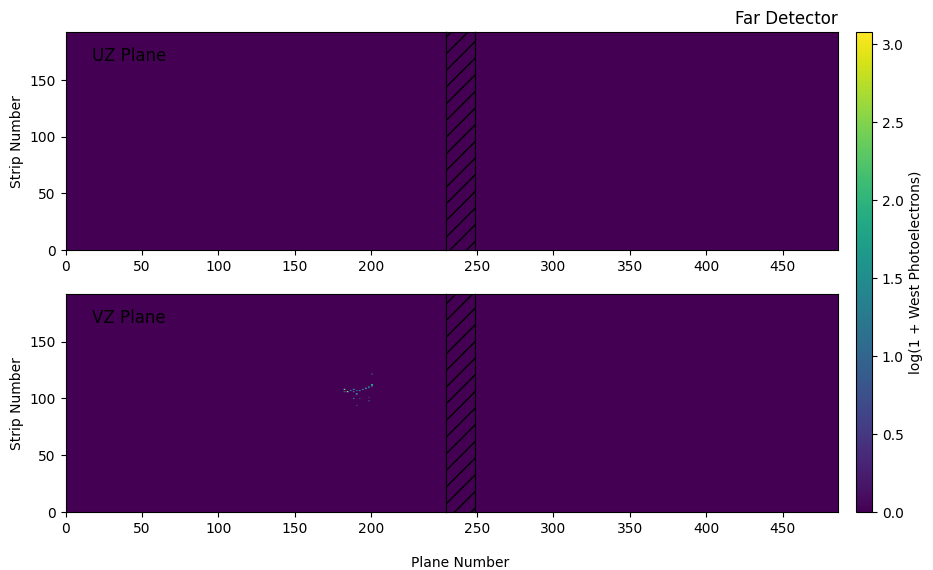

In [6]:
# Pass event record fields using full paths
fig, axs = plot_fd_event_image(
    stp_planeview=event["NtpStRecord/stp/stp.planeview"],
    stp_strip=event["NtpStRecord/stp/stp.strip"],
    stp_plane=event["NtpStRecord/stp/stp.plane"],
    fill=event["NtpStRecord/stp/stp.ph0.pe"],
    use_log_scale=True,
    cbar_label="West Photoelectrons",
    figsize=(12, 6),
)

plt.show()